In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import figurefirst as fifi
###
from mpl_toolkits import mplot3d

import matplotlib as mpl
plt.rcParams['font.serif'] = ['Times'] + plt.rcParams['font.serif']

plt.rcParams['text.usetex'] = False
plt.rcParams["ps.usedistiller"] = 'xpdf'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'normal'
plt.rcParams["mathtext.fontset"] = 'cm'


In [2]:
layout = fifi.svg_to_axes.FigureLayout('f3_altitude_updated.svg', autogenlayers=True, make_mplfigures=True, hide_layers=[])



FileNotFoundError: [Errno 2] No such file or directory: 'f3_altitude_updated.svg'

# Bottom Half On

In [3]:
bottom_on_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/all_nights_new_processing_protocol_bottom_laminar_09092024.hdf')


In [4]:

df_flash_bottom_on = bottom_on_df.groupby("obj_id_unique").filter(lambda d: (np.any(d.Flash_bool)==True) and (np.all(d.duration>0)) and (d['z'].min() >= -0.01))

df_sham_bottom_on = bottom_on_df.groupby("obj_id_unique").filter(lambda d: (np.all(d.duration==0)) and (d['z'].min() >= -0.01))


In [5]:
flash_low_bottom_on = df_flash_bottom_on.groupby("obj_id_unique").filter(lambda d: d[d['time stamp'].between(0,675)].z.mean()<0.25)
flash_up_bottom_on  = df_flash_bottom_on.groupby("obj_id_unique").filter(lambda d: d[d['time stamp'].between(0,675)].z.mean()>0.25)

sham_low_bottom_on =df_sham_bottom_on.groupby("obj_id_unique").filter(lambda d: d[d['time stamp'].between(0,675)].z.mean()<0.25)
sham_up_bottom_on =df_sham_bottom_on.groupby("obj_id_unique").filter(lambda d: d[d['time stamp'].between(0,675)].z.mean()>0.25)

Text(3, 0.5, 'n=510')

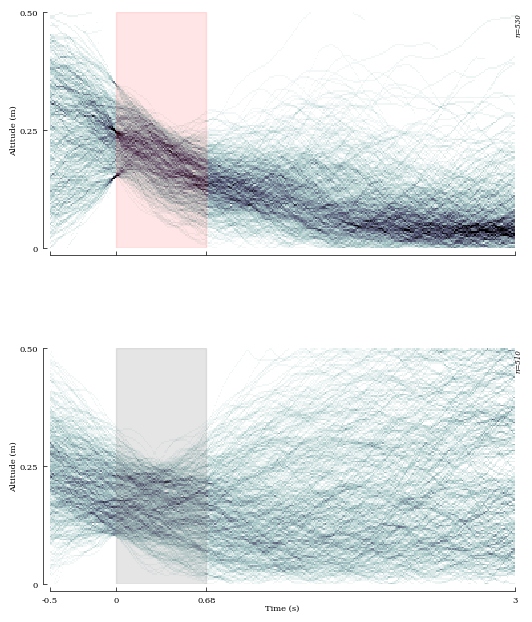

In [6]:
fig, ax = plt.subplots(figsize=(6,8), ncols=1,nrows=2)
cmap_reversed = plt.colormaps.get_cmap('bone_r')
ax[0] = layout.axes[('a', 'A')]
ax[1] = layout.axes[('a', 'B')]

df1_left = flash_low_bottom_on#.groupby("obj_id_unique").filter(lambda d: np.any(d['z'])>0)
df1_left = df1_left.groupby("obj_id_unique").filter(lambda d: np.any(d.duplicate_obj_id_bool)==False)
n_flash = len(df1_left.obj_id_unique.unique())
a = np.arange(-.500,3.000,.010)
b =  np.linspace(0.0, 0.5, 151)
y = np.linspace(0.0, 0.5, 152)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d( df1_left['time stamp']/1000,df1_left['z'], bins =(x,y), density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[0].pcolormesh(X,Y, newdf_normed, vmin=0, vmax=0.05, cmap='bone_r', shading='flat', rasterized=True)
ax[0].set_xticklabels([])


df1_left = sham_low_bottom_on#.groupby("obj_id_unique").filter(lambda d: np.mean(d['ground speed'])>0.15)# df_sham.groupby(['obj_id']).filter(lambda d: d[d['time stamp'].between(0,680)].z.mean()>.25 )
df1_left = df1_left.groupby("obj_id_unique").filter(lambda d: np.any(d.duplicate_obj_id_bool)==False)
sham_ids = df1_left[df1_left['time stamp']==0].groupby('obj_id_unique').filter(lambda d: (d['x'].between(-.35,0.35)) & (d['y'].between(-0.1,0.1)) & (d['z'].between(0.1,0.35))).obj_id_unique
df1_left = df1_left [df1_left.obj_id_unique.isin(list(sham_ids))]
a = np.arange(-.5,3,.010)
b =  np.linspace(0.0, 0.5, 151)
y = np.linspace(0, 0.5, 152)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d(df1_left['time stamp']/1000,df1_left['z'],  bins =(x, y),density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=.05, cmap='bone_r', shading='flat', rasterized=True,)


fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[0,0.25,.50],  xticks=[-.5, 0, .68, 3],spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)
ax[0].set_xticklabels(['', '', '', ''])

fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[0,0.25,.50],  xticks=[-.5, 0, .68, 3], spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)
ax[0].set_yticklabels(['0', '0.25', '0.50'])
ax[1].set_yticklabels(['0', '0.25', '0.50'])
ax[1].set_xticklabels(['-0.5', '0', '0.68', '3'])
    
ax[0].set_aspect(3.55) 
ax[1].set_aspect(3.55)
#ax[0].set_rasterized(True)
#ax[1].set_rasterized(True)

ax[0].set_ylabel('Altitude (m)', labelpad=1)
ax[1].set_ylabel('Altitude (m)', labelpad=1)
ax[1].set_xlabel('Time (s)', labelpad=0)




ax[0].axvspan(0, .675, color = 'red', edgecolor=None, alpha = 0.1)
ax[1].axvspan(0, .675, color = 'grey', edgecolor=None, alpha = 0.2) 

fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)
   

ax[0].text(x=3,y=0.5, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(n_flash), fontsize=5,fontstyle='italic',rotation=90, bbox=dict(facecolor='white', edgecolor='white', pad=0.05,alpha=0.7))
ax[1].text(x=3,y=0.5, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5, rotation=90,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7))



layout.append_figure_to_layer(layout.figures['a'], 'a', cleartarget=True)



Text(3, 0.5, 'n=639')

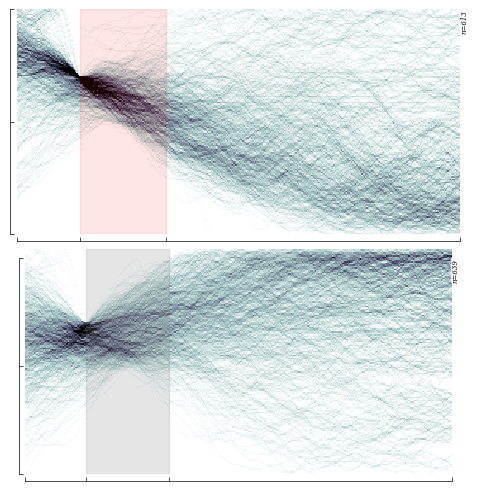

In [7]:

fig, ax = plt.subplots(ncols=1,nrows=2, layout='constrained')
cmap_reversed = plt.colormaps.get_cmap('bone_r')

ax[0] = layout.axes[('c', 'E')]
ax[1] = layout.axes[('c', 'F')]



df1_left = flash_up_bottom_on#[~flash_up_bottom_on.obj_id_unique.isin(sub2.obj_id_unique.unique())]
df1_left = df1_left.groupby("obj_id_unique").filter(lambda d: np.any(d.duplicate_obj_id_bool)==False)
n_flash = len(df1_left.obj_id_unique.unique())
a = np.arange(-.500,3.000,.010)
b =  np.linspace(0.0, 0.5, 151)
y = np.linspace(0, 0.5, 152)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d( df1_left['time stamp']/1000,df1_left['z'], bins =(x,y), density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[0].pcolormesh(X,Y, newdf_normed, vmin=0, vmax=0.05, cmap='bone_r', shading='flat', rasterized=True)




df1_left = sham_up_bottom_on# df_sham.groupby(['obj_id']).filter(lambda d: d[d['time stamp'].between(0,680)].z.mean()>.25 )
df1_left = df1_left.groupby("obj_id_unique").filter(lambda d: np.any(d.duplicate_obj_id_bool)==False)
sham_ids = df1_left[df1_left['time stamp']==0].groupby('obj_id_unique').filter(lambda d: (d['x'].between(-.35,0.35)) & (d['y'].between(-0.1,0.1)) & (d['z'].between(0.1,0.35))).obj_id_unique
df1_left = df1_left [df1_left.obj_id_unique.isin(list(sham_ids))]
a = np.arange(-.5,3,.010)
b =  np.linspace(0, 0.52, 151)
y = np.linspace(0, 0.52, 152)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d(df1_left['time stamp']/1000,df1_left['z'],  bins =(x, y),density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=.05, cmap='bone_r', shading='flat', rasterized=True,)

    


fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[0,0.25,.50],  xticks=[-.5, 0, .68, 3],spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)
ax[0].set_xticklabels(['', '', '', ''])
ax[0].set_yticklabels(['', '', '',])

fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[0,0.25,.50],  xticks=[-.5, 0, .68, 3], spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)
ax[1].set_xticklabels(['', '', '', ''])
ax[1].set_yticklabels(['', '', '',])


ax[0].axvspan(0, .675, color = 'red', edgecolor=None, alpha = 0.1)
ax[1].axvspan(0, .675, color = 'grey', edgecolor=None, alpha = 0.2) 

    
ax[0].set_aspect(3.55) 
ax[1].set_aspect(3.55)
#ax[0].set_rasterized(True)
#ax[1].set_rasterized(True)


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)

ax[0].text(x=3,y=0.5, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(n_flash), fontsize=5,fontstyle='italic',rotation=90, bbox=dict(facecolor='white', edgecolor='white', pad=0.05,alpha=0.7))
ax[1].text(x=3,y=0.5, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5, rotation=90,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7))

   

layout.append_figure_to_layer(layout.figures['c'], 'c', cleartarget=True)


# Top Half On

In [8]:
top_on_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/all_nights_new_processing_protocol_top_laminar_09082024.hdf')

In [9]:
df_flash_top_on= top_on_df.groupby("obj_id_unique").filter(lambda d: (np.any(d.Flash_bool)==True) and (np.all(d.duration>0)) and (d['z'].min() >= -0.01))
df_sham_top_on  = top_on_df.groupby("obj_id_unique").filter(lambda d: (np.all(d.duration==0)) and (d['z'].min() >= -0.01))


In [10]:
flash_low_top_on = df_flash_top_on.groupby("obj_id_unique").filter(lambda d: d[d['time stamp'].between(0,675)].z.mean()<0.25)
flash_up_top_on  = df_flash_top_on.groupby("obj_id_unique").filter(lambda d: d[d['time stamp'].between(0,675)].z.mean()>0.25)


sham_low_top_on =df_sham_top_on.groupby("obj_id_unique").filter(lambda d: d[d['time stamp'].between(0,675)].z.mean()<0.25)
sham_up_top_on =df_sham_top_on.groupby("obj_id_unique").filter(lambda d: d[d['time stamp'].between(0,675)].z.mean()>0.25)

Text(3, 0.5, 'n=620')

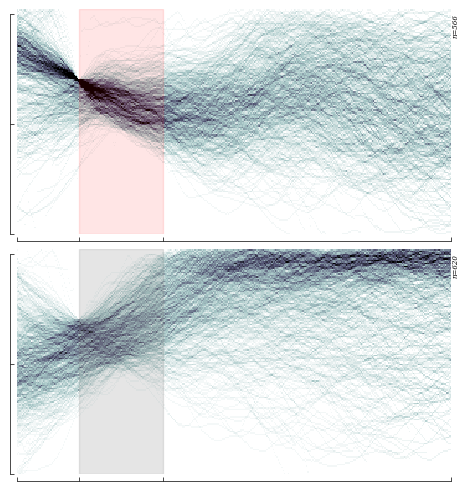

In [11]:

fig, ax = plt.subplots(ncols=1,nrows=2, layout='constrained')
cmap_reversed = plt.colormaps.get_cmap('bone_r')


ax[0] = layout.axes[('b', 'C')]
ax[1] = layout.axes[('b', 'D')]


df1_left = flash_up_top_on
df1_left = df1_left.groupby("obj_id_unique").filter(lambda d: np.any(d.duplicate_obj_id_bool)==False)
n_flash = len(df1_left.obj_id_unique.unique())
a = np.arange(-.500,3.000,.010)
b =  np.linspace(0, 0.51, 151)
y = np.linspace(0, 0.51, 152)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d( df1_left['time stamp']/1000,df1_left['z'], bins =(x,y), density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[0].pcolormesh(X,Y, newdf_normed, vmin=0, vmax=0.05, cmap='bone_r', shading='flat', rasterized=True)


df1_left = sham_up_top_on
df1_left = df1_left.groupby("obj_id_unique").filter(lambda d: np.any(d.duplicate_obj_id_bool)==False)
sham_ids = df1_left[df1_left['time stamp']==0].groupby('obj_id_unique').filter(lambda d: (d['x'].between(-.35,0.35)) & (d['y'].between(-0.1,0.1)) & (d['z'].between(0.1,0.35))).obj_id_unique
df1_left = df1_left [df1_left.obj_id_unique.isin(list(sham_ids))]
a = np.arange(-.5,3,.010)
b =  np.linspace(0, 0.51, 151)
y = np.linspace(0, 0.51, 152)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d(df1_left['time stamp']/1000,df1_left['z'],  bins =(x, y),density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=.05, cmap='bone_r', shading='flat', rasterized=True,)



fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[0,0.25,.50],  xticks=[-.5, 0, .68, 3],spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)
ax[0].set_xticklabels(['', '', '', ''])
ax[0].set_yticklabels(['', '', '',])

fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[0,0.25,.50],  xticks=[-.5, 0, .68, 3], spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)
ax[1].set_xticklabels(['', '', '', ''])
ax[1].set_yticklabels(['', '', '',])


ax[0].axvspan(0, .675, color = 'red', edgecolor=None, alpha = 0.1)
ax[1].axvspan(0, .675, color = 'grey', edgecolor=None, alpha = 0.2) 

ax[0].set_aspect(3.55) 
ax[1].set_aspect(3.55)
#ax[0].set_rasterized(True)
#ax[1].set_rasterized(True)


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)

ax[0].text(x=3,y=0.5, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(n_flash), fontsize=5,fontstyle='italic',rotation=90, bbox=dict(facecolor='white', edgecolor='white', pad=0.05,alpha=0.7))
ax[1].text(x=3,y=0.5, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5, rotation=90,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7))




layout.append_figure_to_layer(layout.figures['b'], 'b', cleartarget=True)



Text(3, 0.5, 'n=454')

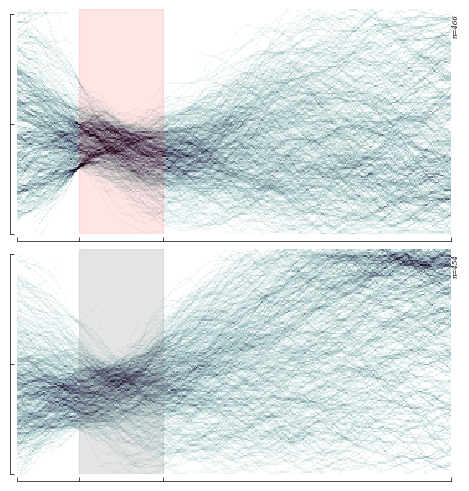

In [12]:
fig, ax = plt.subplots(ncols=1,nrows=2, layout='constrained')
cmap_reversed = plt.colormaps.get_cmap('bone_r')
ax[0] = layout.axes[('d', 'G')]
ax[1] = layout.axes[('d', 'H')]
df1_left = flash_low_top_on
df1_left = df1_left.groupby("obj_id_unique").filter(lambda d: np.any(d.duplicate_obj_id_bool)==False)
n_flash = len(df1_left.obj_id_unique.unique())
a = np.arange(-.500,3.000,.010)
b =  np.linspace(0, 0.51, 151)
y = np.linspace(0, 0.51, 152)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d( df1_left['time stamp']/1000,df1_left['z'], bins =(x,y), density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[0].pcolormesh(X,Y, newdf_normed, vmin=0, vmax=0.05, cmap='bone_r', shading='flat', rasterized=True)




df1_left = sham_low_top_on# df_sham.groupby(['obj_id']).filter(lambda d: d[d['time stamp'].between(0,680)].z.mean()>.25 )
df1_left = df1_left.groupby("obj_id_unique").filter(lambda d: np.any(d.duplicate_obj_id_bool)==False)
sham_ids = df1_left[df1_left['time stamp']==0].groupby('obj_id_unique').filter(lambda d: (d['x'].between(-.35,0.35)) & (d['y'].between(-0.1,0.1)) & (d['z'].between(0.1,0.35))).obj_id_unique
df1_left = df1_left [df1_left.obj_id_unique.isin(list(sham_ids))]
a = np.arange(-.5,3,.010)
b =  np.linspace(0, 0.51, 151)
y = np.linspace(0, 0.51, 152)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d(df1_left['time stamp']/1000,df1_left['z'],  bins =(x, y),density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=.05, cmap='bone_r', shading='flat', rasterized=True,)




fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[0,0.25,.50],  xticks=[-.5, 0, .68, 3],spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)
ax[0].set_xticklabels(['', '', '', ''])
ax[0].set_yticklabels(['', '', '',])

fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[0,0.25,.50],  xticks=[-.5, 0, .68, 3], spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)
ax[1].set_xticklabels(['', '', '', ''])
ax[1].set_yticklabels(['', '', '',])


ax[0].axvspan(0, .675, color = 'red', edgecolor=None, alpha = 0.1)
ax[1].axvspan(0, .675, color = 'grey', edgecolor=None, alpha = 0.2) 
  
ax[0].set_aspect(3.55) 
ax[1].set_aspect(3.55)
#ax[0].set_rasterized(True)
#ax[1].set_rasterized(True)


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)


ax[0].text(x=3,y=0.5, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(n_flash), fontsize=5,fontstyle='italic',rotation=90, bbox=dict(facecolor='white', edgecolor='white', pad=0.05,alpha=0.7))
ax[1].text(x=3,y=0.5, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5, rotation=90,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7))



layout.append_figure_to_layer(layout.figures['d'], 'd', cleartarget=True)



# color bar

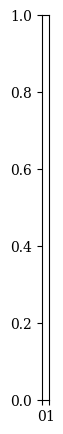

In [121]:
#cmap_base = 'bone_r'
#vmin, vmax = 0, 0.05
#Spectral_half_cmap = truncate_colormap(cmap_base, vmin, vmax)


fig, ax = plt.subplots(figsize=(.1,5))
ax = layout.axes[('CB', 'cb')] 




sm = mpl.cm.ScalarMappable(cmap='bone_r', norm=mpl.colors.Normalize(vmin=0, vmax=0.05)) 
fig.colorbar(sm, cax=ax,  orientation='vertical')
fifi.mpl_functions.adjust_spines(ax, ['right'], yticks=[0,0.05], spine_locations={'right':0}, tick_length=3, linewidth=1)
ax.set_yticklabels(['0','0.05'])

fifi.mpl_functions.set_fontsize(ax, 6)
ax.set_aspect(500)

layout.append_figure_to_layer(layout.figures['CB'], 'CB', cleartarget=True)




### Save to Inkscape svg

In [31]:
layout.write_svg('f3_altitude.svg')

# 3D Example trajectories 

### note: can't save 3D plots directly to Inkscape via FigureFirst, have to save and manually add

In [18]:
t1 = flash_low_bottom_on[flash_low_bottom_on.obj_id_unique=='7224_20240516_185822']
t2 = flash_up_top_on[flash_up_top_on.obj_id_unique=='5522_20240515_182700']


t3 = flash_up_bottom_on[flash_up_bottom_on.obj_id_unique=='12712_20240516_185822']
t4 = flash_low_top_on[flash_low_top_on.obj_id_unique=='8802_20240514_172126']

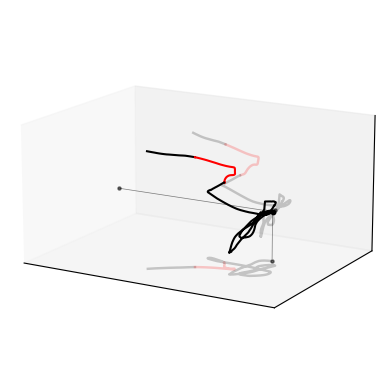

In [19]:

pre=t3[t3['time stamp'].between(-200, 0)]
dur=t3[t3['time stamp'].between(0, 675)]
post = t3[t3['time stamp'].between(675,5000)]

fig = plt.figure()
ax = plt.axes(projection ='3d')

#ax = layout.axes[('c2', 'S')]

ax.plot(pre['x'], pre['y'], pre['z'], color = 'k', linewidth = 1.5)
ax.plot(pre['x'], pre['y'], -.06, color ='k', alpha = 0.2, linewidth = 1.75)
ax.plot(dur['x'], dur['y'], dur['z'], color = 'red', linewidth = 1.5)
ax.plot(dur['x'], dur['y'], -.06, color ='red', alpha = 0.2, linewidth = 1.75)
ax.plot(post['x'], post['y'], post['z'], color = 'k', linewidth = 1.5)
ax.plot(post['x'], post['y'], -0.06, color ='k', alpha = 0.2, linewidth = 1.75)
ax.scatter(post['x'].iloc[-1], post['y'].iloc[-1], post['z'].iloc[-1], color = 'k', s= 10)

ax.plot(pre['x'], [.25]*len(pre), pre['z'], color ='k', alpha = 0.2, linewidth = 1.75)
ax.plot(dur['x'], [.25]*len(dur), dur['z'], color ='red', alpha = 0.2, linewidth = 1.75)
ax.plot(post['x'], [.25]*len(post), post['z'], color ='k', alpha = 0.2, linewidth = 1.75)

ax.scatter(post['x'].iloc[-1], post['y'].iloc[-1], -0.06, color = 'k', alpha = 0.5, s=5)
ax.scatter(post['x'].iloc[-1], .25, post['z'].iloc[-1], color = 'k', alpha = 0.5, s= 5)
ax.scatter(-.5, post['y'].iloc[-1], post['z'].iloc[-1], color = 'k', alpha = 0.5, s=5)

ax.plot((post['x'].iloc[-1],post['x'].iloc[-1]), (post['y'].iloc[-1],post['y'].iloc[-1]),(post['z'].iloc[-1], -0.05),linewidth =.5, color = 'k', alpha = 0.5)
ax.plot((post['x'].iloc[-1],-.5), (post['y'].iloc[-1],post['y'].iloc[-1]),(post['z'].iloc[-1], post['z'].iloc[-1]),linewidth = 0.5, color = 'k', alpha = 0.5)
ax.plot((post['x'].iloc[-1],post['x'].iloc[-1]), (post['y'].iloc[-1],.25),(post['z'].iloc[-1], post['z'].iloc[-1]), linewidth = 0.5, color = 'k', alpha = 0.5)


ax.view_init(15)
ax.set_xlim(-.5, .5)
ax.set_ylim(-.40, .35)
ax.set_zlim(0, .5)
ax.set_aspect('equal')

ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
#plt.savefig(path +"/3d_projection_for_f3_v2.jpg", dpi = 300, transparent =True)
plt.savefig("3d_projection_t3", dpi = 300, transparent =True)

#layout.append_figure_to_layer(layout.figures['c2'], 'c2', cleartarget=True)

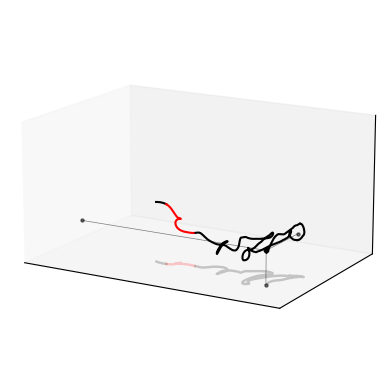

In [20]:

pre=t1[t1['time stamp'].between(-200, 0)]
dur=t1[t1['time stamp'].between(0, 675)]
post = t1[t1['time stamp'].between(675,5000)]

fig = plt.figure()
ax = plt.axes(projection ='3d')
#ax = layout.axes[('a2', 'Q')]


ax.plot(pre['x'], pre['y'], pre['z'], color = 'k', linewidth = 1.5)
ax.plot(pre['x'], pre['y'], -.06, color ='k', alpha = 0.2, linewidth = 1.75)
ax.plot(dur['x'], dur['y'], dur['z'], color = 'red', linewidth = 1.5)
ax.plot(dur['x'], dur['y'], -.06, color ='red', alpha = 0.2, linewidth = 1.75)
ax.plot(post['x'], post['y'], post['z'], color = 'k', linewidth = 1.5)
ax.plot(post['x'], post['y'], -0.06, color ='k', alpha = 0.2, linewidth = 1.75)

ax.scatter(post['x'].iloc[-1], post['y'].iloc[-1], post['z'].iloc[-1], s= 10, color = 'k')

#ax.plot(pre['x'], [.25]*len(pre), pre['z'], color ='k', alpha = 0.2, linewidth = 1.75)
#ax.plot(dur['x'], [.25]*len(dur), dur['z'], color ='red', alpha = 0.2, linewidth = 1.75)
#ax.plot(post['x'], [.25]*len(post), post['z'], color ='k', alpha = 0.2, linewidth = 1.75)

ax.scatter(post['x'].iloc[-1], post['y'].iloc[-1], -0.06, color = 'k', alpha = 0.5, s=5)
ax.scatter(post['x'].iloc[-1], .25, post['z'].iloc[-1], color = 'k', alpha = 0.5, s= 5)
ax.scatter(-.5, post['y'].iloc[-1], post['z'].iloc[-1], color = 'k', alpha = 0.5, s=5)

ax.plot((post['x'].iloc[-1],post['x'].iloc[-1]), (post['y'].iloc[-1],post['y'].iloc[-1]),(post['z'].iloc[-1], -0.05),linewidth =.5, color = 'k', alpha = 0.5)
ax.plot((post['x'].iloc[-1],-.5), (post['y'].iloc[-1],post['y'].iloc[-1]),(post['z'].iloc[-1], post['z'].iloc[-1]),linewidth = 0.5, color = 'k', alpha = 0.5)
ax.plot((post['x'].iloc[-1],post['x'].iloc[-1]), (post['y'].iloc[-1],.25),(post['z'].iloc[-1], post['z'].iloc[-1]), linewidth = 0.5, color = 'k', alpha = 0.5)


ax.view_init(15)
ax.set_xlim(-.5, .5)
ax.set_ylim(-.35, .35)
ax.set_zlim(0, .5)
ax.set_aspect('equal')

ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
plt.savefig("3d_projection_t1", dpi = 300, transparent =True)


#layout.append_figure_to_layer(layout.figures['a2'], 'a2', cleartarget=True)

[]

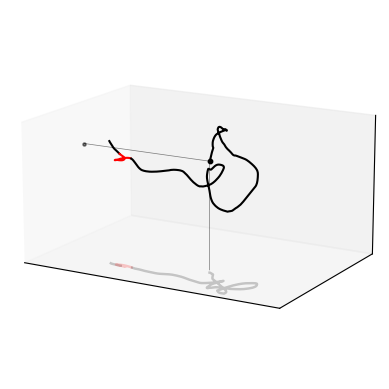

In [21]:

pre=t2[t2['time stamp'].between(-200, 0)]
dur=t2[t2['time stamp'].between(0, 675)]
post = t2[t2['time stamp'].between(675,5000)]

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
#ax = layout.axes[('b2', 'R')]
#ax = plt.axes(projection ='3d')



ax.plot(pre['x'], pre['y'], pre['z'], color = 'k', linewidth = 1.5)
ax.plot(pre['x'], pre['y'], -.06, color ='k', alpha = 0.2, linewidth = 1.75)
ax.plot(dur['x'], dur['y'], dur['z'], color = 'red', linewidth = 1.5)
ax.plot(dur['x'], dur['y'], -.06, color ='red', alpha = 0.2, linewidth = 1.75)
ax.plot(post['x'], post['y'], post['z'], color = 'k', linewidth = 1.5)
ax.plot(post['x'], post['y'], -0.06, color ='k', alpha = 0.2, linewidth = 1.75)
ax.scatter(post['x'].iloc[-1], post['y'].iloc[-1], post['z'].iloc[-1], color = 'k', s= 10)

#ax.plot(pre['x'], [.25]*len(pre), pre['z'], color ='k', alpha = 0.2, linewidth = 1.75)
#ax.plot(dur['x'], [.25]*len(dur), dur['z'], color ='red', alpha = 0.2, linewidth = 1.75)
#ax.plot(post['x'], [.25]*len(post), post['z'], color ='k', alpha = 0.2, linewidth = 1.75)

#ax.scatter(post['x'].iloc[-1], post['y'].iloc[-1], -0.06, color = 'k', alpha = 0.5, s=5)
#ax.scatter(post['x'].iloc[-1], .25, post['z'].iloc[-1], color = 'k', alpha = 0.5, s= 5)
ax.scatter(-.5, post['y'].iloc[-1], post['z'].iloc[-1], color = 'k', alpha = 0.5, s=5)

ax.plot((post['x'].iloc[-1],post['x'].iloc[-1]), (post['y'].iloc[-1],post['y'].iloc[-1]),(post['z'].iloc[-1], -0.05),linewidth =.5, color = 'k', alpha = 0.5)
ax.plot((post['x'].iloc[-1],-.5), (post['y'].iloc[-1],post['y'].iloc[-1]),(post['z'].iloc[-1], post['z'].iloc[-1]),linewidth = 0.5, color = 'k', alpha = 0.5)
#ax.plot((post['x'].iloc[-1],post['x'].iloc[-1]), (post['y'].iloc[-1],.25),(post['z'].iloc[-1], post['z'].iloc[-1]), linewidth = 0.5, color = 'k', alpha = 0.5)


ax.view_init(15)
ax.set_xlim(-.5, .5)
ax.set_ylim(-.35, .35)
ax.set_zlim(0, .5)
ax.set_aspect('equal')

ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

#plt.savefig("3d_projection_t2", dpi = 300, transparent =True)

#layout.append_figure_to_layer(layout.figures['b2'], 'b2', cleartarget=True)

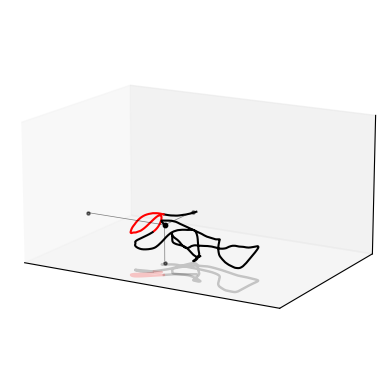

In [22]:

pre=t4[t4['time stamp'].between(-200, 0)]
dur=t4[t4['time stamp'].between(0, 675)]
post = t4[t4['time stamp'].between(675,5000)]

fig = plt.figure()
ax = plt.axes(projection ='3d')
#ax = layout.axes[('d2', 'X')]


ax.plot(pre['x'], pre['y'], pre['z'], color = 'k', linewidth = 1.5)
ax.plot(pre['x'], pre['y'], -.06, color ='k', alpha = 0.2, linewidth = 1.75)
ax.plot(dur['x'], dur['y'], dur['z'], color = 'red', linewidth = 1.5)
ax.plot(dur['x'], dur['y'], -.06, color ='red', alpha = 0.2, linewidth = 1.75)
ax.plot(post['x'], post['y'], post['z'], color = 'k', linewidth = 1.5)
ax.plot(post['x'], post['y'], -0.06, color ='k', alpha = 0.2, linewidth = 1.75)
ax.scatter(post['x'].iloc[-1], post['y'].iloc[-1], post['z'].iloc[-1], color = 'k', s= 10)

#ax.plot(pre['x'], [.25]*len(pre), pre['z'], color ='k', alpha = 0.2, linewidth = 1.75)
#ax.plot(dur['x'], [.25]*len(dur), dur['z'], color ='red', alpha = 0.2, linewidth = 1.75)
#ax.plot(post['x'], [.25]*len(post), post['z'], color ='k', alpha = 0.2, linewidth = 1.75)

ax.scatter(post['x'].iloc[-1], post['y'].iloc[-1], -0.06, color = 'k', alpha = 0.5, s=5)
ax.scatter(post['x'].iloc[-1], .25, post['z'].iloc[-1], color = 'k', alpha = 0.5, s= 5)
ax.scatter(-.5, post['y'].iloc[-1], post['z'].iloc[-1], color = 'k', alpha = 0.5, s=5)

ax.plot((post['x'].iloc[-1],post['x'].iloc[-1]), (post['y'].iloc[-1],post['y'].iloc[-1]),(post['z'].iloc[-1], -0.05),linewidth =.5, color = 'k', alpha = 0.5)
ax.plot((post['x'].iloc[-1],-.5), (post['y'].iloc[-1],post['y'].iloc[-1]),(post['z'].iloc[-1], post['z'].iloc[-1]),linewidth = 0.5, color = 'k', alpha = 0.5)
ax.plot((post['x'].iloc[-1],post['x'].iloc[-1]), (post['y'].iloc[-1],.25),(post['z'].iloc[-1], post['z'].iloc[-1]), linewidth = 0.5, color = 'k', alpha = 0.5)


ax.view_init(15)
ax.set_xlim(-.5, .5)
ax.set_ylim(-.35, .35)
ax.set_zlim(0, .5)
ax.set_aspect('equal')

ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
#plt.savefig(path +"/3d_projection_for_f3_v2.jpg", dpi = 300, transparent =True)
plt.savefig("3d_projection_t4", dpi = 300, transparent =True)

#layout.append_figure_to_layer(layout.figures['d2'], 'd2', cleartarget=True)